# Sven vs Adam: Toy 1D Regression

This notebook demonstrates the Sven optimizer on a simple 1D regression task and compares it to Adam.

The target function is $f(x) = e^{-10x^2} \sin(2x)$, sampled uniformly on $[-1, 1]$.

In [1]:
import torch
import torch.nn as nn
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from sven.nn import SvenWrapper
from sven.opt import Sven

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


## Dataset

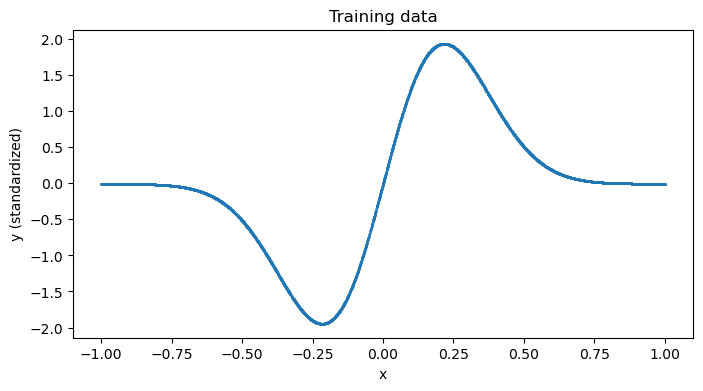

In [2]:
def target_fn(x):
    return torch.exp(-10 * x**2) * torch.sin(2 * x)

torch.manual_seed(0)
n_train, n_val = 10_000, 10_000

xtrain = 2 * torch.rand(n_train, 1) - 1
xval   = 2 * torch.rand(n_val, 1) - 1
ytrain = target_fn(xtrain)
yval   = target_fn(xval)

# Standardize targets
mean, std = ytrain.mean(), ytrain.std()
ytrain = (ytrain - mean) / std
yval   = (yval - mean) / std

batch_size = 128
train_loader = DataLoader(TensorDataset(xtrain, ytrain), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(xval, yval), batch_size=n_val, shuffle=False)

plt.figure(figsize=(8, 4))
plt.scatter(xtrain.numpy(), ytrain.numpy(), s=1, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y (standardized)')
plt.title('Training data')
plt.show()

## Define models

We use two identical MLPs (same architecture, same initial weights) so the comparison is fair.

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dims[0]), nn.GELU()]
        for i in range(1, len(hidden_dims)):
            layers.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
            layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dims[-1], output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
mlp_adam = MLP(1, [16, 16, 16], 1).to(device)
mlp_sven = MLP(1, [16, 16, 16], 1).to(device)
mlp_sven.load_state_dict(mlp_adam.state_dict())

n_params = sum(p.numel() for p in mlp_adam.parameters())
print(f'Parameters: {n_params}')

Parameters: 593


## Train with Adam

In [4]:
optimizer_adam = torch.optim.Adam(mlp_adam.parameters(), lr=1e-3)
loss_fn_adam = nn.MSELoss()
num_epochs = 100

losses_adam = defaultdict(list)

# Record untrained validation loss
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn_adam(mlp_adam(xb), yb)
        losses_adam['val'].append(loss.item())

for epoch in tqdm(range(num_epochs)):
    epoch_train, epoch_val = [], []
    mlp_adam.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_adam.zero_grad()
        loss = loss_fn_adam(mlp_adam(xb), yb)
        loss.backward()
        optimizer_adam.step()
        epoch_train.append(loss.item())
    mlp_adam.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn_adam(mlp_adam(xb), yb)
            epoch_val.append(loss.item())
    losses_adam['train'].append(np.mean(epoch_train))
    losses_adam['val'].append(np.mean(epoch_val))

100%|██████████| 100/100 [00:06<00:00, 15.38it/s]


## Train with Sven

Key differences from the Adam loop:
1. The model is wrapped with `SvenWrapper`, which takes a **per-sample** loss function (returns shape `(B,)`, not a scalar).
2. `wrapped.loss_and_grad(batch)` replaces the usual `loss.backward()` — it computes the per-sample Jacobian internally.
3. The entire loop runs under `torch.no_grad()` since Sven does not use autograd for the parameter update.

In [5]:
# Per-sample MSE loss: must return (B,) not a scalar
def loss_fn_sven(pred, y):
    return ((pred - y) ** 2).sum(dim=-1)

wrapped = SvenWrapper(mlp_sven, loss_fn_sven, device)
optimizer_sven = Sven(wrapped, lr=0.1, k=batch_size // 2, rtol=1e-3)

losses_sven = defaultdict(list)

# Record untrained validation loss
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn_sven(wrapped.evaluate(xb), yb).mean()
        losses_sven['val'].append(loss.item())

with torch.no_grad():
    for epoch in tqdm(range(num_epochs)):
        epoch_train, epoch_val = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch_losses, preds = wrapped.loss_and_grad((xb, yb))
            optimizer_sven.step()
            epoch_train.append(batch_losses.mean().item())
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn_sven(wrapped.evaluate(xb), yb).mean()
            epoch_val.append(loss.item())
        losses_sven['train'].append(np.mean(epoch_train))
        losses_sven['val'].append(np.mean(epoch_val))

100%|██████████| 100/100 [00:38<00:00,  2.59it/s]


## Compare results

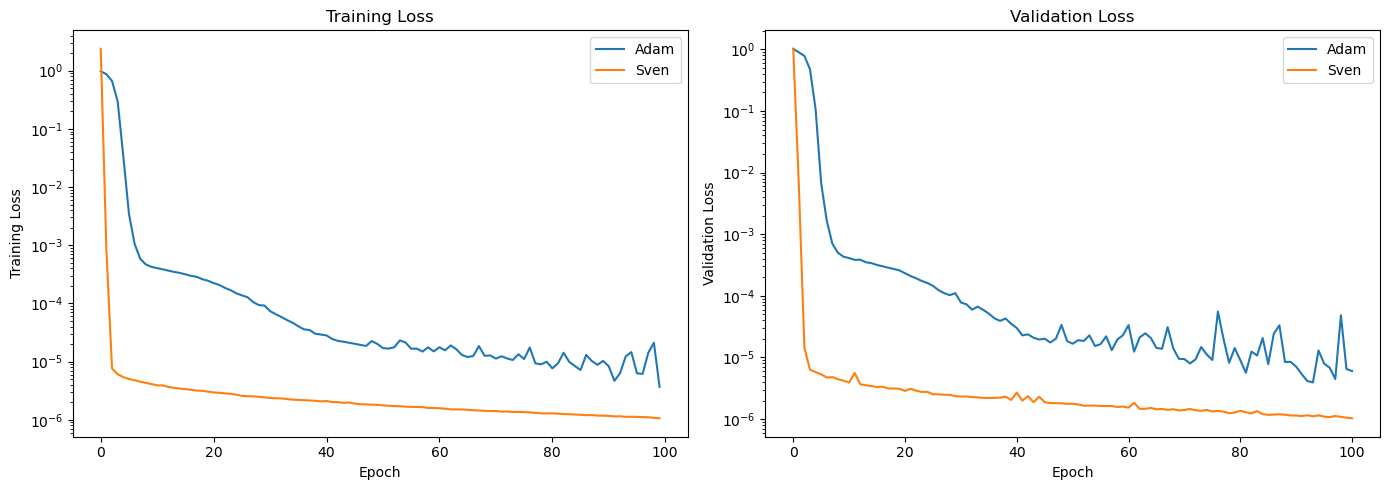

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(losses_adam['train'], label='Adam')
axes[0].plot(losses_sven['train'], label='Sven')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('Training Loss')

# Validation loss
axes[1].plot(losses_adam['val'], label='Adam')
axes[1].plot(losses_sven['val'], label='Sven')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Validation Loss')

plt.tight_layout()
plt.show()

## Visualize predictions

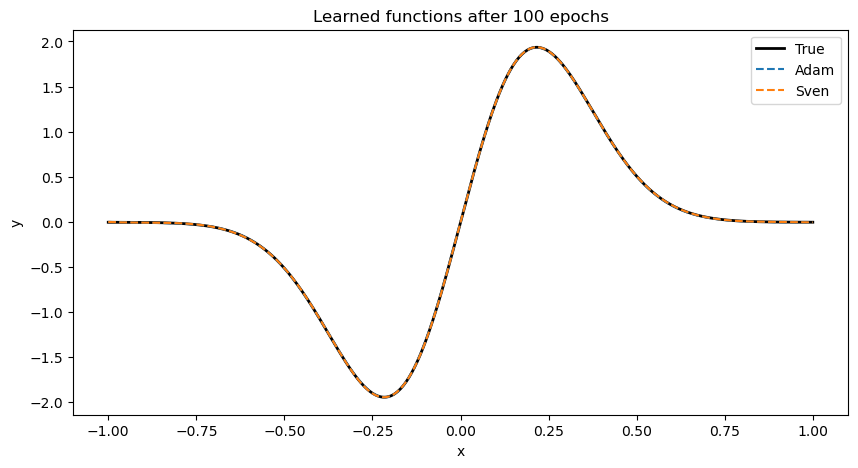

In [7]:
x_plot = torch.linspace(-1, 1, 500).unsqueeze(1).to(device)
y_true = (target_fn(x_plot) - mean) / std

with torch.no_grad():
    y_adam = mlp_adam(x_plot)
    y_sven = wrapped.evaluate(x_plot)

x_np = x_plot.cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(x_np, y_true.cpu().numpy(), 'k-', lw=2, label='True')
plt.plot(x_np, y_adam.cpu().numpy(), '--', lw=1.5, label='Adam')
plt.plot(x_np, y_sven.cpu().numpy(), '--', lw=1.5, label='Sven')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Learned functions after 100 epochs')
plt.show()